# Krigagem
Notebook separado para testes de krigagem e visualizacao discretizada por percentil.


In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from importlib import reload
from pykrige.ok import OrdinaryKriging

try:
    import spatial_metrics
except ModuleNotFoundError:
    from src import spatial_metrics

spatial_metrics = reload(spatial_metrics)
ide_isi_from_pykrige = spatial_metrics.ide_isi_from_pykrige
kriging_mae = spatial_metrics.kriging_mae

modelos = {"krigagem": []}

altitude = []
data_folder = "../data/"
altitude.append(pd.read_csv(data_folder + "Altitude_2025-10-14T20_07_43.980Z.csv"))
altitude.append(pd.read_csv(data_folder + "Altitude_2025-10-14T20_15_03.183Z.csv"))


In [8]:
def discretize_by_percentile(values, n_divisions=3):
    if n_divisions <= 0:
        raise ValueError("n_divisions deve ser maior que zero.")
    arr = np.asarray(np.ma.filled(values, np.nan), dtype=float)
    flat = arr.reshape(-1)
    valid_mask = np.isfinite(flat)
    if valid_mask.sum() == 0:
        return np.full(arr.shape, np.nan)
    valid_values = flat[valid_mask]
    quantiles = np.linspace(0, 1, int(n_divisions) + 1)
    edges = np.nanquantile(valid_values, quantiles)
    edges = np.unique(edges)
    classes_flat = np.full(flat.shape, np.nan)
    if len(edges) <= 1:
        classes_flat[valid_mask] = 1
    else:
        bins = np.digitize(valid_values, edges[1:-1], right=True) + 1
        classes_flat[valid_mask] = bins.astype(float)
    return classes_flat.reshape(arr.shape)


In [9]:
def save_krigagem_metrics(variant: str, variogram_parameters: dict, mae_medio: float):
    isi_info = ide_isi_from_pykrige(variogram_parameters)
    row = {
        "modelo": "krigagem",
        "kernel": variant,
        "mae_medio": mae_medio,
        "ide": isi_info["ide"],
        "isi": isi_info["isi"],
        "classe_isi": isi_info["classe_isi"],
        "nugget": isi_info["nugget"],
        "structured_variance": isi_info["structured_variance"],
    }
    output_path = Path("../models/svr_metrics.csv")
    output_path.parent.mkdir(parents=True, exist_ok=True)
    columns = ["modelo", "kernel", "mae_medio", "ide", "isi", "classe_isi", "nugget", "structured_variance"]
    if output_path.exists():
        results_df = pd.read_csv(output_path)
        if "modelo" not in results_df.columns:
            results_df.insert(0, "modelo", "svr")
        results_df = results_df[~((results_df["modelo"] == "krigagem") & (results_df["kernel"] == variant))]
        results_df = pd.concat([results_df, pd.DataFrame([row])], ignore_index=True)
    else:
        results_df = pd.DataFrame([row])
    results_df = results_df.reindex(columns=columns)
    results_df.to_csv(output_path, index=False)
    return row


def krigering(data, variant="exponential", n_divisions=3):
    data_unique = data.groupby(["x", "y"], as_index=False).mean()
    x = data_unique["x"].astype(float)
    y = data_unique["y"].astype(float)
    z = data_unique["Altitude"].astype(float)
    gridx = np.linspace(x.min(), x.max(), 80)
    gridy = np.linspace(y.min(), y.max(), 80)
    vrange = 304 / 111000
    variogram_parameters = {"sill": 97.6, "range": vrange, "nugget": 0}
    OK = OrdinaryKriging(x=x, y=y, z=z, variogram_model=variant, variogram_parameters=variogram_parameters, enable_plotting=False)
    zz, ss = OK.execute("grid", gridx, gridy)
    modelos["krigagem"].append(OK)
    mae_medio = kriging_mae(
        {"x": x, "y": y, "z": z},
        variogram_model=variant,
        variogram_parameters=variogram_parameters,
    )
    krigagem_metrics = save_krigagem_metrics(variant, variogram_parameters, mae_medio)
    print(
        f"Krigagem ({variant}) - MAE: {mae_medio:.4f} - IDE: {krigagem_metrics['ide']:.2f}% - "
        f"ISI: {krigagem_metrics['isi']:.2f}% ({krigagem_metrics['classe_isi']})"
    )
    zz_disc = discretize_by_percentile(zz, n_divisions=n_divisions)
    n_classes = int(np.nanmax(zz_disc)) if np.isfinite(zz_disc).any() else 1
    cmap = sns.color_palette("viridis", n_colors=max(n_classes, 1))
    sns.heatmap(zz_disc, cmap=cmap, vmin=1, vmax=max(n_classes, 1), cbar_kws={"label": "Classe (percentil)"})
    plt.title(f"Krigagem ({variant}) - {n_divisions} divisoes")
    plt.show()
    return zz, ss


Krigagem (exponential) - MAE: 0.2155 - IDE: 100.00% - ISI: 0.00% (forte)


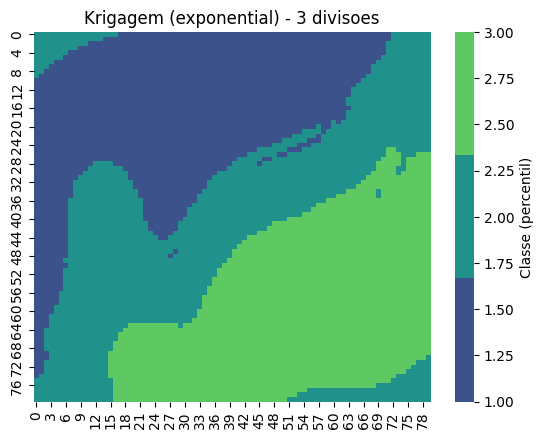

(masked_array(
   data=[[657.1957690632694, 657.1013468200049, 657.0086539162098, ...,
          658.171067509724, 658.4120028195747, 658.6201563579742],
         [657.0994102686499, 656.9994086059097, 656.9013278316621, ...,
          658.3002807748136, 658.5335015562932, 658.7346571016365],
         [656.9991098448153, 656.8931525658602, 656.7893153136546, ...,
          658.4402949456237, 658.6645595810132, 658.8577363047515],
         ...,
         [656.6862351397466, 657.0257495378182, 657.4700214904184, ...,
          662.6287905731513, 662.4958001231245, 662.3609826274601],
         [656.9355548709628, 657.2543568902685, 657.6636037613408, ...,
          662.4621863397397, 662.3373401968031, 662.2106451402924],
         [657.1636862251377, 657.4632882588759, 657.841235186664, ...,
          662.3025849844794, 662.1854511566913, 662.0664551302502]],
   mask=[[False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False,

In [10]:
krigering(altitude[0])
